In [1]:
from model_ranking import (
    load_h5,
    get_roi_slice,
    get_random_colors,
)
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from plantseg.functionals.dataprocessing.labelprocessing import set_background_to_value, set_biggest_instance_to_zero, relabel_segmentation
from plantseg.functionals.segmentation import dt_watershed, gasp

INFO: P [MainThread] 2026-07-23 10:35:24,217 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
OV_gt_path = "/scratch/talks/data/Ovules/GT2x/test/N_294_final_crop_ds2.h5"
label_key = "label_with_ignore"
raw_key = "raw"

OV_gt = load_h5(OV_gt_path, label_key)
OV_raw = load_h5(OV_gt_path, raw_key)
print(OV_gt.shape, OV_raw.shape)

(320, 960, 1000) (320, 960, 1000)


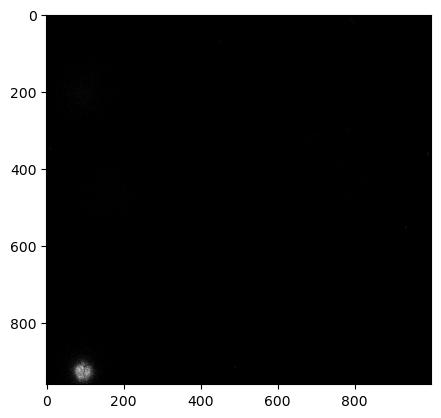

In [6]:
plt.imshow(OV_raw[0], cmap="gray")
plt.show()

# Flywing to Ovules

In [7]:
pred_path_NA = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P_fullslice/fw_model_Unet2/norm_50_950/none/predictions/N_294_final_crop_ds2_predictions.h5"
preds_NA = load_h5(pred_path_NA, "predictions")
segs_NA = load_h5(pred_path_NA, "segmentation")
MAP_score_NA = load_h5(pred_path_NA, "MAP_05_095")
patch_indexes = load_h5(pred_path_NA, "patch_index")
print(preds_NA.shape, MAP_score_NA.shape)

(320, 1, 1, 960, 1000) (320,)


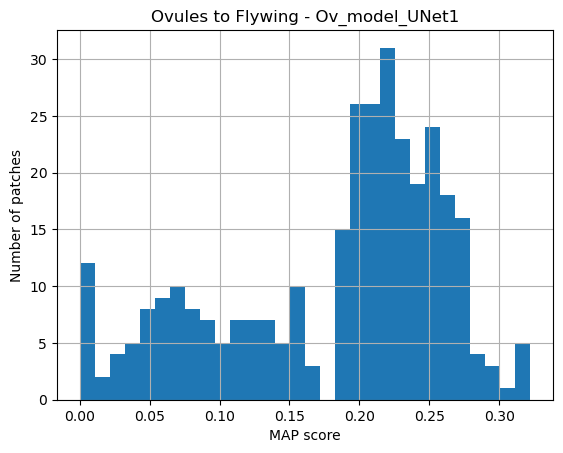

In [10]:
plt.hist(MAP_score_NA, bins=30)
plt.xlabel("MAP score")
plt.ylabel("Number of patches")
plt.title("Ovules to Flywing - Ov_model_UNet1")
plt.grid()
plt.show()

In [15]:
ids = np.where(MAP_score_NA > 0.25)[0]
print(len(ids), "patches with MAP score > 0.25")

66 patches with MAP score > 0.25


In [13]:
i = ids[201]
plt.imshow(preds_NA[i].squeeze(), cmap="magma")
plt.imshow()

IndexError: index 201 is out of bounds for axis 0 with size 66

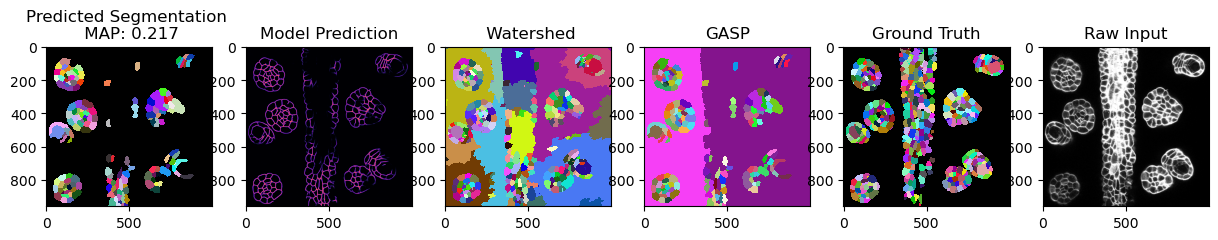

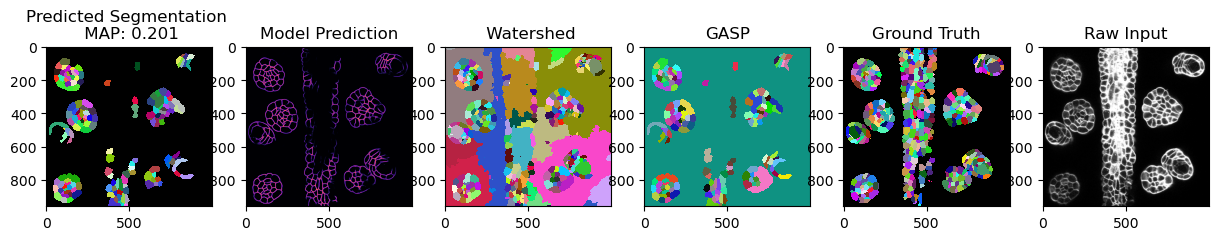

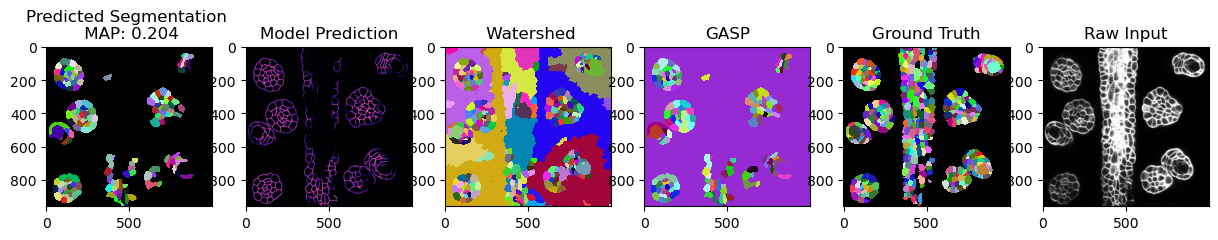

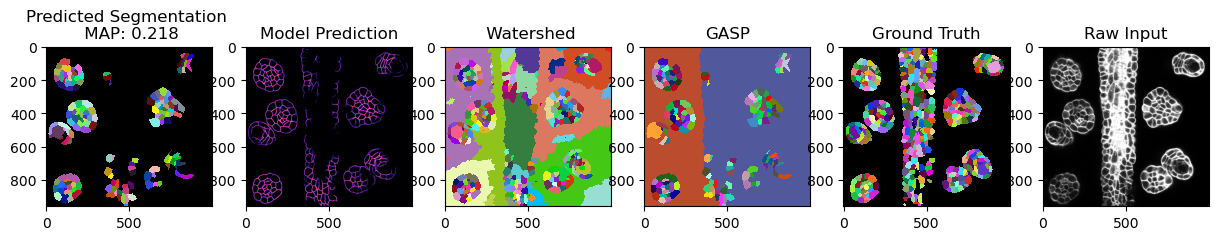

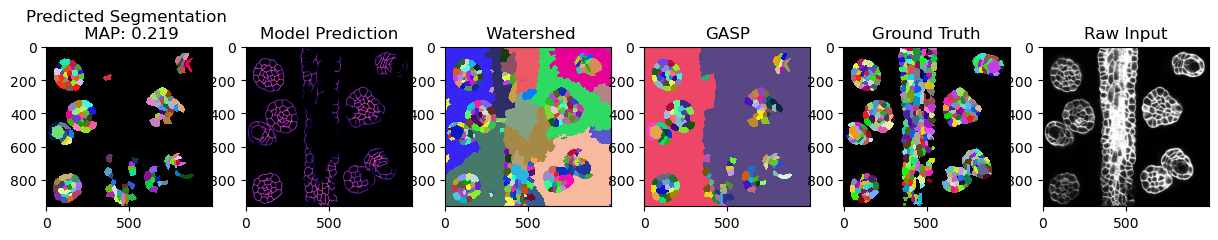

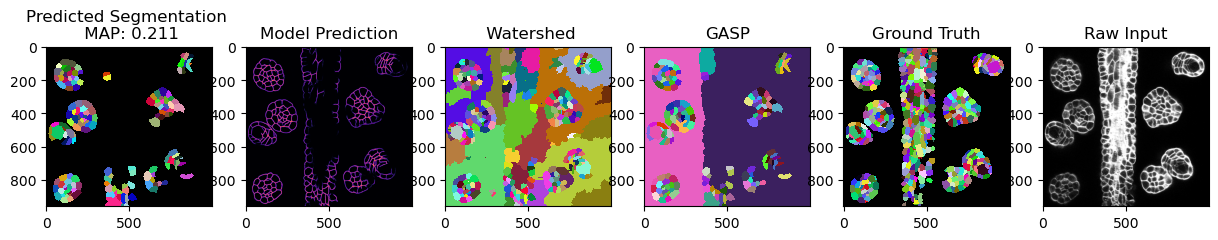

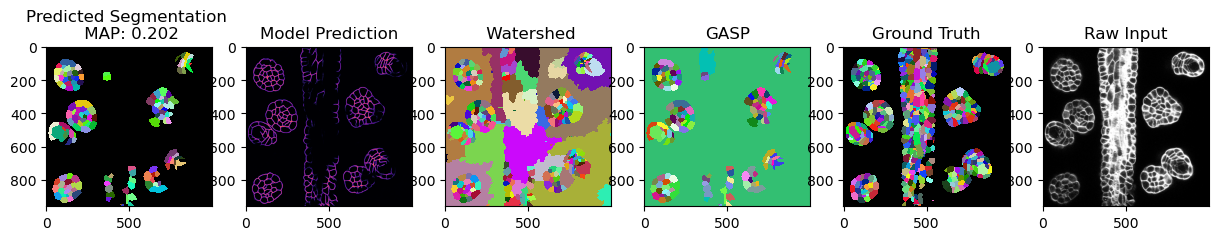

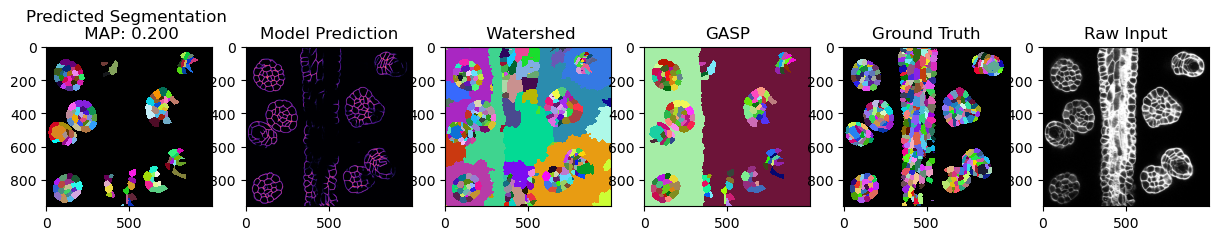

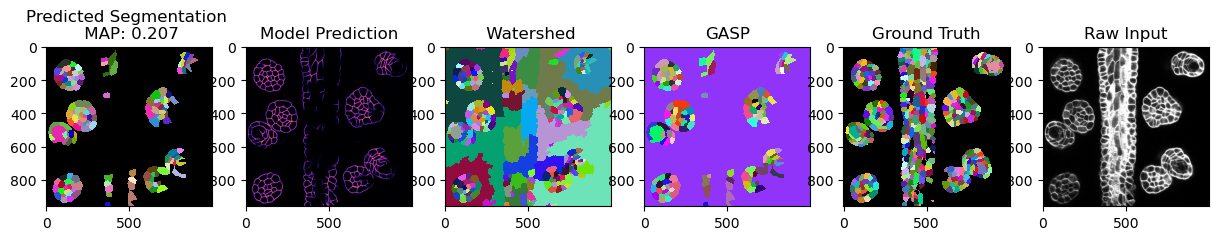

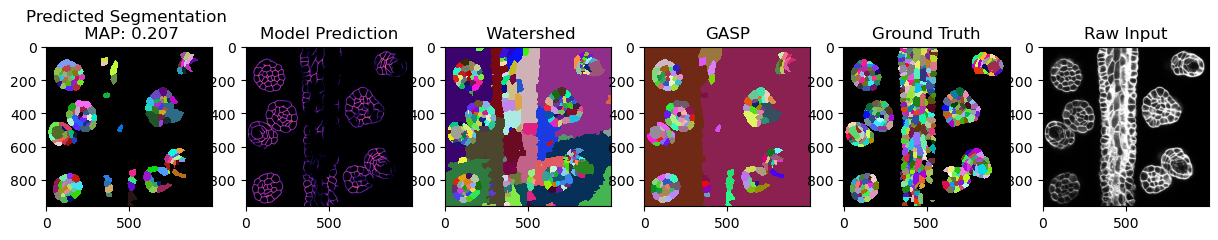

In [16]:
for i in range(200, 210):
    patch_roi = get_roi_slice(patch_indexes[i])
    pred_wt = dt_watershed(preds_NA[i].squeeze(), threshold=0.5, stacked=False, min_size=5)
    gasp_pred = gasp(preds_NA[i].squeeze(), pred_wt, post_minsize=50, beta=0.5)
    _, axs = plt.subplots(1, 6, figsize=(15, 5))
    axs[0].imshow(segs_NA[i].squeeze(), cmap=get_random_colors(segs_NA[i]), interpolation='nearest')
    axs[0].set_title(f"Predicted Segmentation \n MAP: {MAP_score_NA[i]:.3f}")
    axs[1].imshow(preds_NA[i].squeeze(), cmap="magma")
    axs[1].set_title(f"Model Prediction")
    axs[2].imshow(pred_wt, cmap=get_random_colors(pred_wt), interpolation='nearest')
    axs[2].set_title(f" Watershed")
    axs[3].imshow(gasp_pred, cmap=get_random_colors(gasp_pred), interpolation='nearest')
    axs[3].set_title(f"GASP")
    axs[4].imshow(OV_gt[patch_roi].squeeze(), cmap=get_random_colors(OV_gt[patch_roi]), interpolation='nearest')
    axs[4].set_title(f"Ground Truth")
    axs[5].imshow(OV_raw[patch_roi].squeeze(), cmap="gray")
    axs[5].set_title(f"Raw Input")
    plt.show()

# Ovules to Ovules

In [17]:
pred_path_NA = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/Ovules_to_Ovules_gap/consistency/P_fullslice/ov_model_UNet1/norm_50_950/none/predictions/N_294_final_crop_ds2_predictions.h5"
preds_NA = load_h5(pred_path_NA, "predictions")
segs_NA = load_h5(pred_path_NA, "segmentation")
MAP_score_NA = load_h5(pred_path_NA, "MAP_05_095")
patch_indexes = load_h5(pred_path_NA, "patch_index")
print(preds_NA.shape, MAP_score_NA.shape)

(320, 1, 1, 960, 1000) (320,)


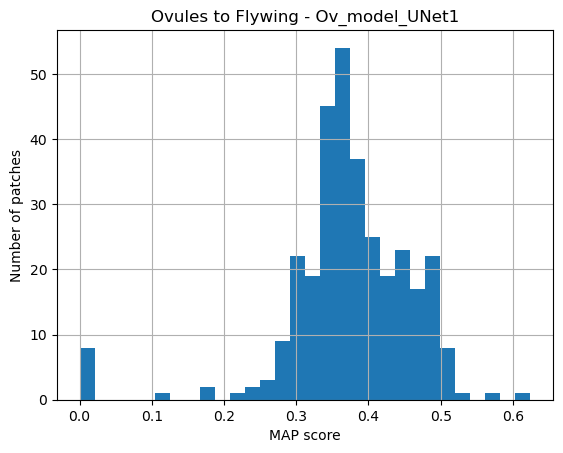

In [18]:
plt.hist(MAP_score_NA, bins=30)
plt.xlabel("MAP score")
plt.ylabel("Number of patches")
plt.title("Ovules to Flywing - Ov_model_UNet1")
plt.grid()
plt.show()

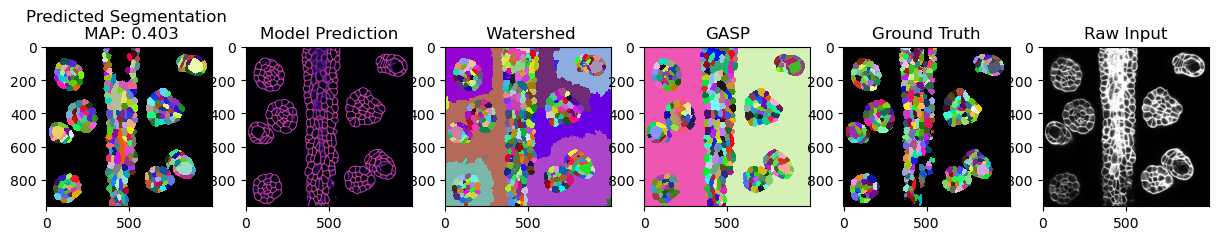

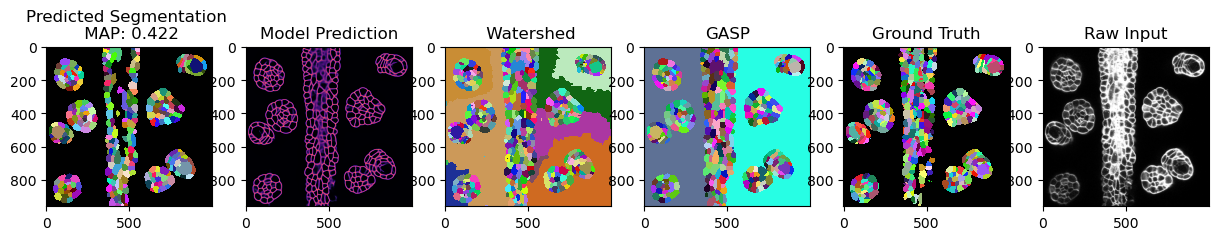

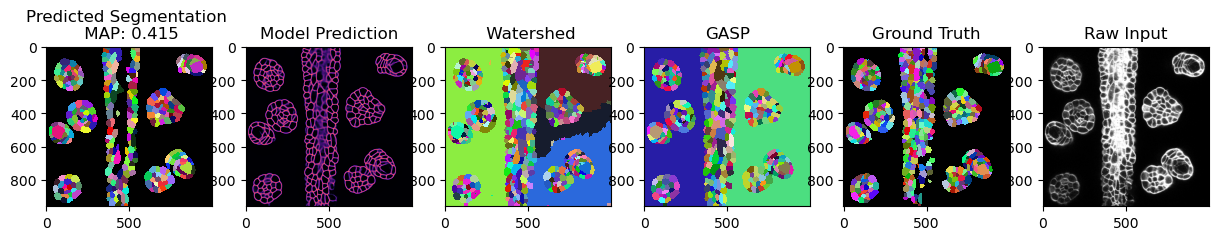

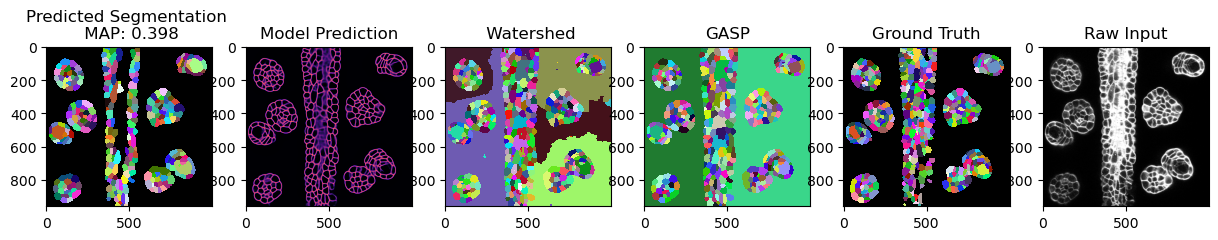

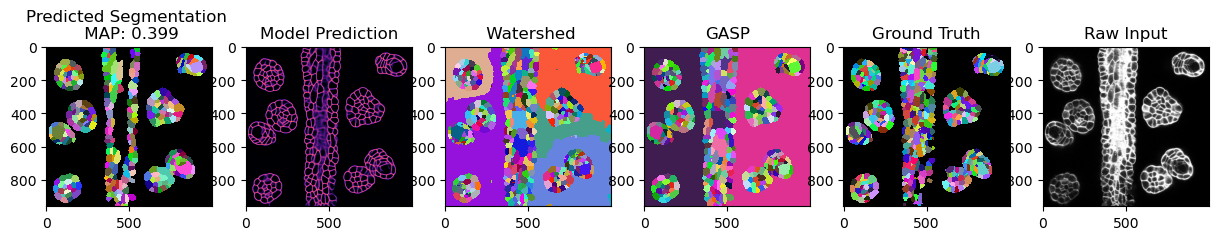

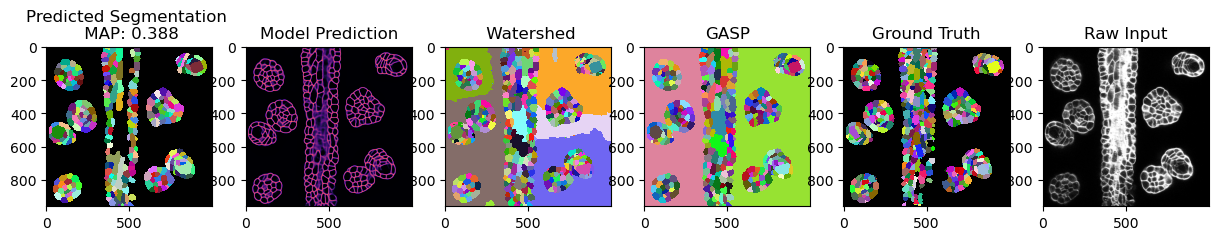

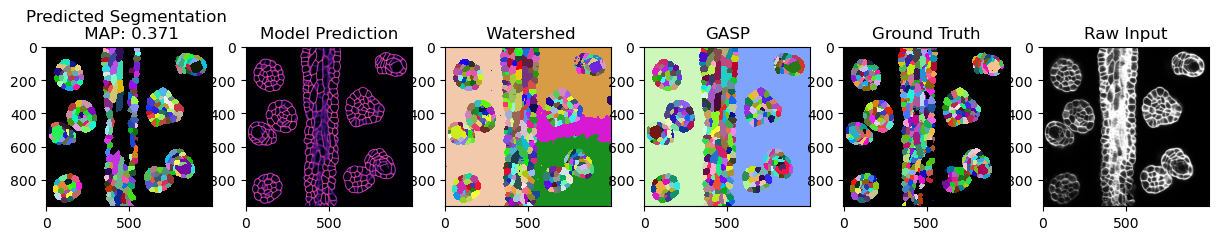

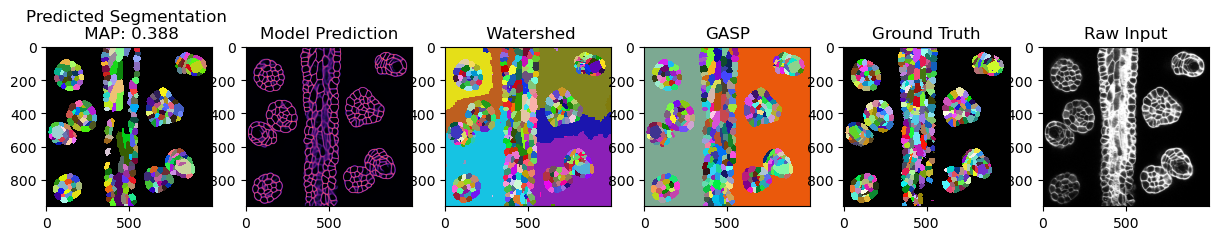

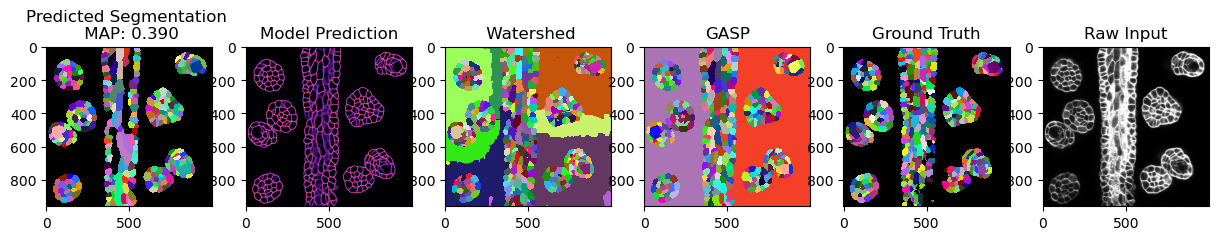

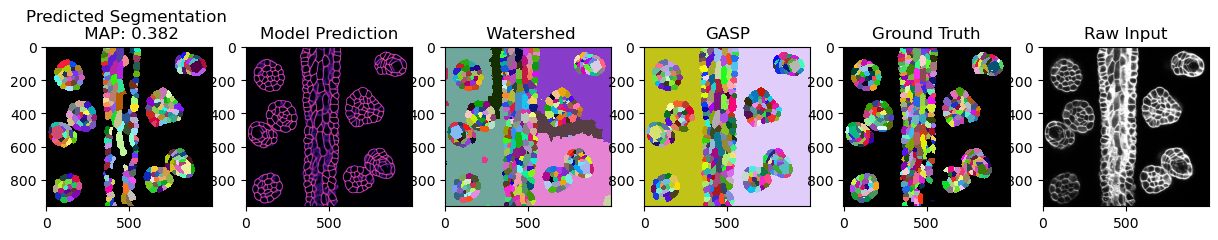

In [20]:
for i in range(200, 210):
    patch_roi = get_roi_slice(patch_indexes[i])
    pred_wt = dt_watershed(preds_NA[i].squeeze(), threshold=0.5, stacked=False, min_size=5)
    gasp_pred = gasp(preds_NA[i].squeeze(), pred_wt, post_minsize=50, beta=0.8)
    _, axs = plt.subplots(1, 6, figsize=(15, 5))
    axs[0].imshow(segs_NA[i].squeeze(), cmap=get_random_colors(segs_NA[i]), interpolation='nearest')
    axs[0].set_title(f"Predicted Segmentation \n MAP: {MAP_score_NA[i]:.3f}")
    axs[1].imshow(preds_NA[i].squeeze(), cmap="magma")
    axs[1].set_title(f"Model Prediction")
    axs[2].imshow(pred_wt, cmap=get_random_colors(pred_wt), interpolation='nearest')
    axs[2].set_title(f" Watershed")
    axs[3].imshow(gasp_pred, cmap=get_random_colors(gasp_pred), interpolation='nearest')
    axs[3].set_title(f"GASP")
    axs[4].imshow(OV_gt[patch_roi].squeeze(), cmap=get_random_colors(OV_gt[patch_roi]), interpolation='nearest')
    axs[4].set_title(f"Ground Truth")
    axs[5].imshow(OV_raw[patch_roi].squeeze(), cmap="gray")
    axs[5].set_title(f"Raw Input")
    plt.show()

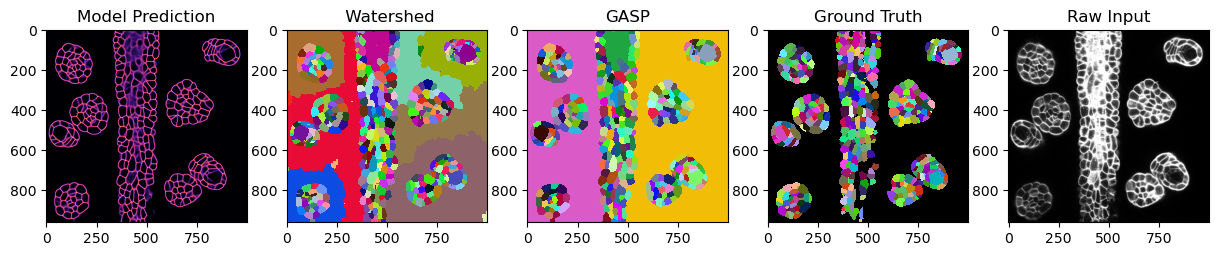

In [ ]:
i=200
patch_roi = get_roi_slice(patch_indexes[i])
pred_wt_03 = dt_watershed(preds_NA[i].squeeze(), threshold=0.3, stacked=False, min_size=5)
pred_wt_04 = dt_watershed(preds_NA[i].squeeze(), threshold=0.4, stacked=False, min_size=5)
pred_wt_05 = dt_watershed(preds_NA[i].squeeze(), threshold=0.5, stacked=False, min_size=5)
pred_wt_06 = dt_watershed(preds_NA[i].squeeze(), threshold=0.6, stacked=False, min_size=5)
pred_wt_07 = dt_watershed(preds_NA[i].squeeze(), threshold=0.7, stacked=False, min_size=5)
gasp_pred_08 = gasp(preds_NA[i].squeeze(), pred_wt, post_minsize=50, beta=0.8)
_, axs = plt.subplots(1, 5, figsize=(15, 5))
axs[0].imshow(preds_NA[i].squeeze(), cmap="magma")
axs[0].set_title(f"Model Prediction")
axs[1].imshow(pred_wt, cmap=get_random_colors(pred_wt), interpolation='nearest')
axs[1].set_title(f" Watershed")
axs[2].imshow(gasp_pred, cmap=get_random_colors(gasp_pred), interpolation='nearest')
axs[2].set_title(f"GASP")
axs[3].imshow(OV_gt[patch_roi].squeeze(), cmap=get_random_colors(OV_gt[patch_roi]), interpolation='nearest')
axs[3].set_title(f"Ground Truth")
axs[4].imshow(OV_raw[patch_roi].squeeze(), cmap="gray")
axs[4].set_title(f"Raw Input")
plt.show()

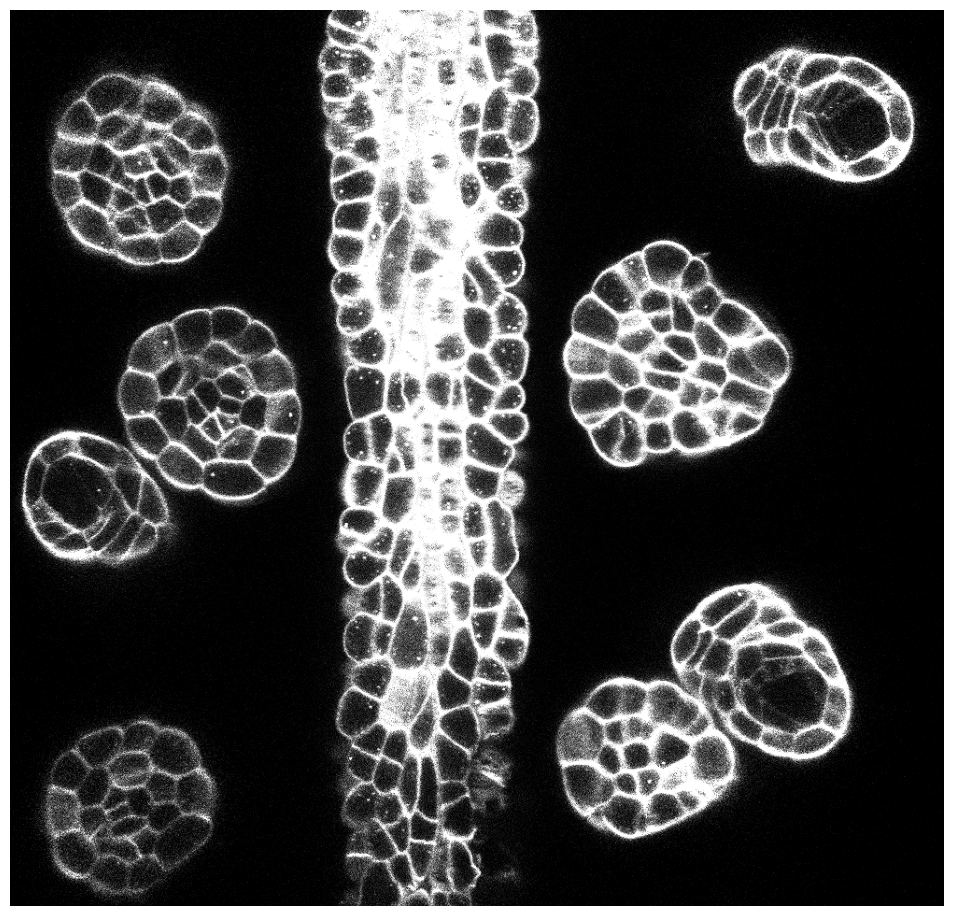

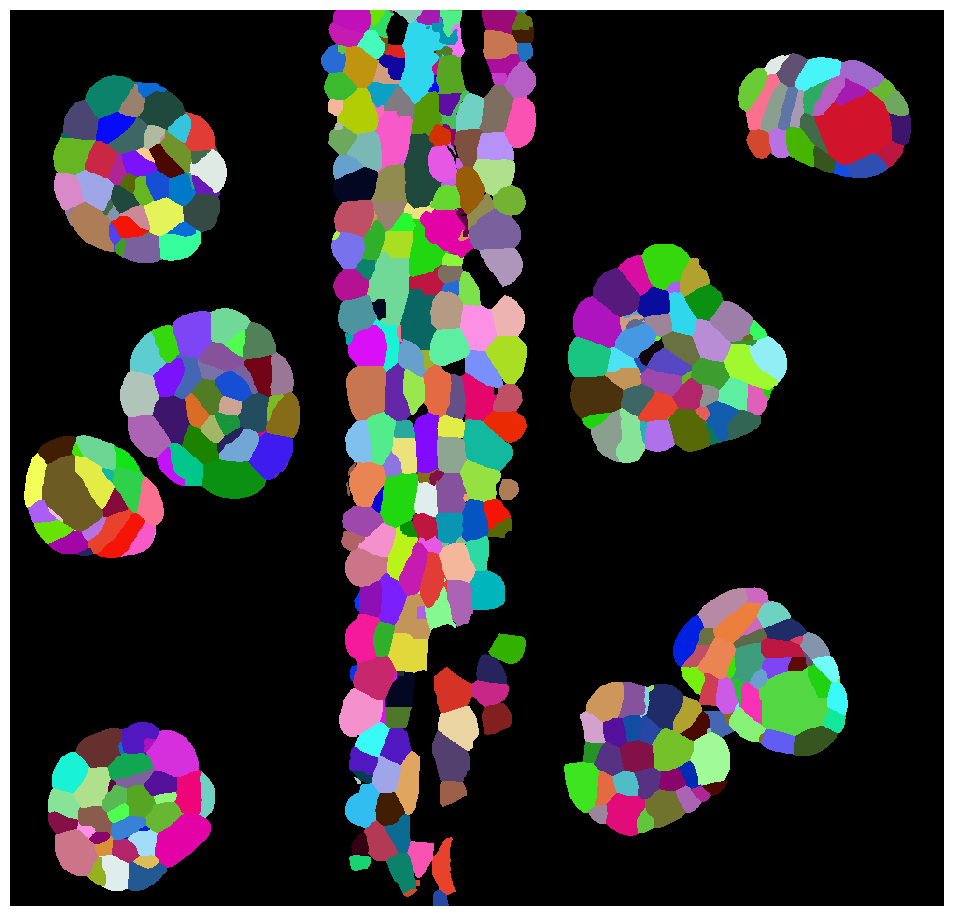

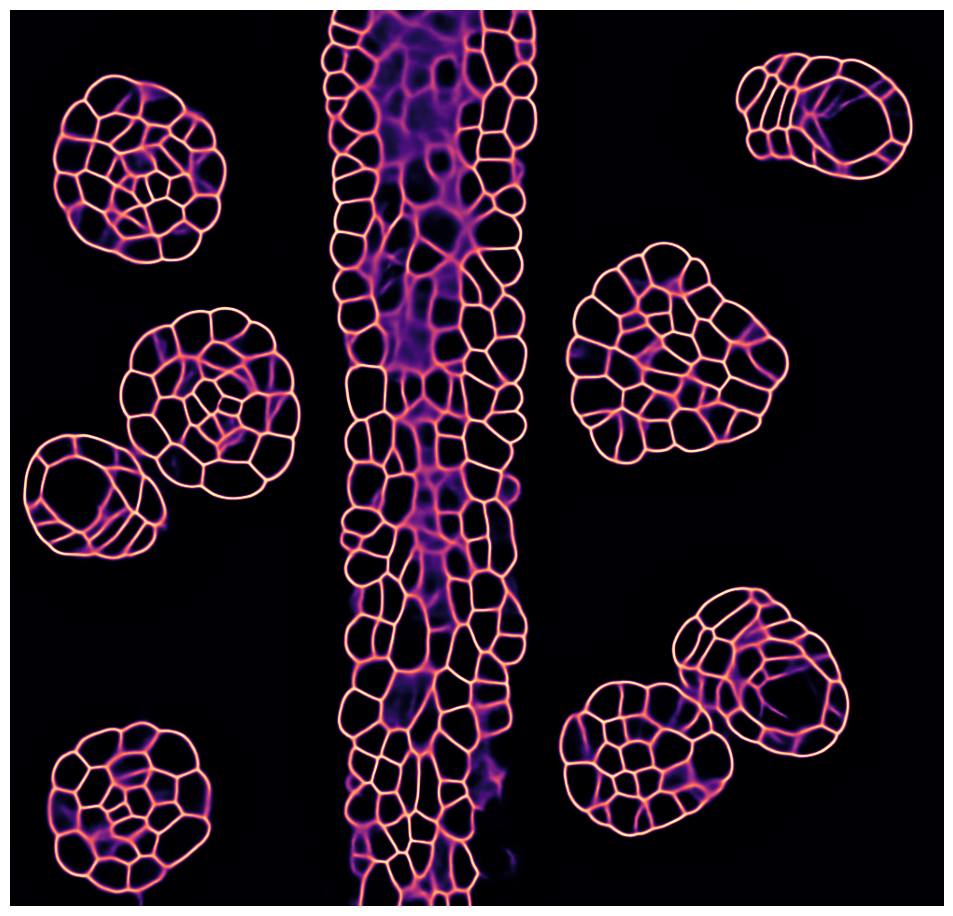

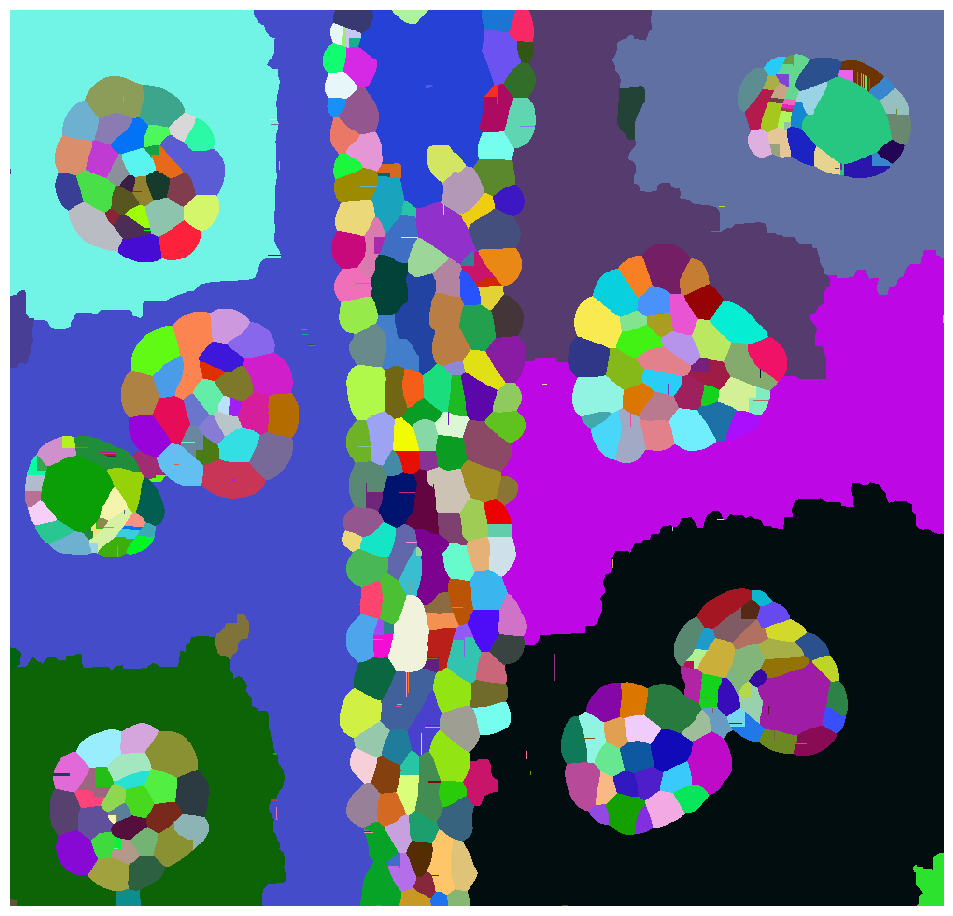

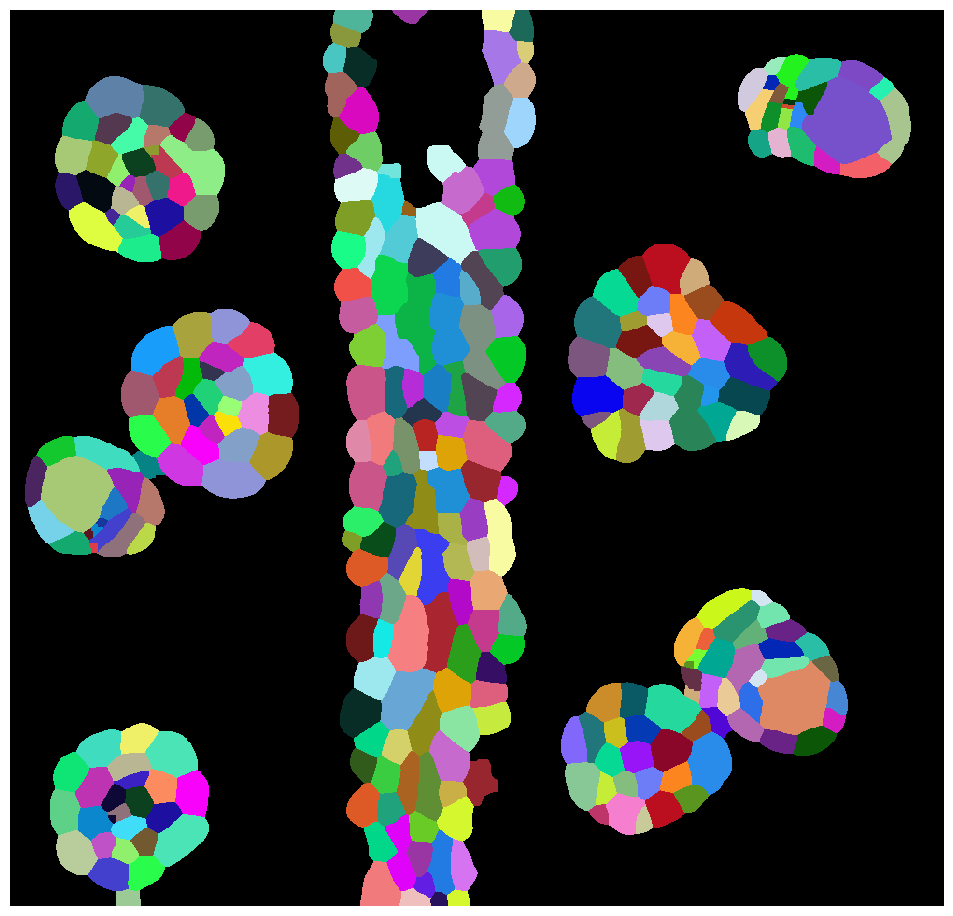

In [33]:
pred_wt = dt_watershed(preds_NA[i].squeeze(), threshold=0.6, stacked=False, min_size=5)
gasp_pred = gasp(preds_NA[i].squeeze(), pred_wt, post_minsize=50, beta=0.8)

gasp_pred = set_biggest_instance_to_zero(gasp_pred)
gasp_pred = set_biggest_instance_to_zero(gasp_pred)
gasp_pred = set_biggest_instance_to_zero(gasp_pred)

_ = plt.figure(figsize=(10, 10))
_ = plt.imshow(OV_raw[i], cmap="gray")
plt.tight_layout()
_ = plt.axis("off")
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/cells/figures/Ovules_raw.png", bbox_inches="tight", pad_inches=0)
plt.show()

_ = plt.figure(figsize=(10, 10))
_ = plt.imshow(OV_gt[i], cmap=get_random_colors(OV_gt[i]), interpolation="none")
plt.tight_layout()
_ = plt.axis("off")
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/cells/figures/Ovules_gt.png", bbox_inches="tight", pad_inches=0)
plt.show()

_ = plt.figure(figsize=(10, 10))
_ = plt.imshow(preds_NA[i].squeeze(), cmap="magma")
plt.tight_layout()
_ = plt.axis("off")
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/cells/figures/Ovules_boundary_pred.png", bbox_inches="tight", pad_inches=0)
plt.show()

_ = plt.figure(figsize=(10, 10))
_ = plt.imshow(pred_wt, cmap=get_random_colors(pred_wt), interpolation="none")
plt.tight_layout()
_ = plt.axis("off")
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/cells/figures/Ovules_watershed.png", bbox_inches="tight", pad_inches=0)
plt.show()

_ = plt.figure(figsize=(10, 10))
_ = plt.imshow(gasp_pred, cmap=get_random_colors(gasp_pred), interpolation="none")
plt.tight_layout()
_ = plt.axis("off")
plt.savefig("/g/kreshuk/talks/model_ranking/notebooks/thesis/cells/figures/Ovules_gasp.png", bbox_inches="tight", pad_inches=0)
plt.show()

In [48]:
import torch
from pytorch3dunet.unet3d.metrics import InstanceAveragePrecision

In [45]:
gasp_pred.shape

(960, 1000)

In [47]:
OV_gt[200].shape

(960, 1000)

In [52]:
torch.from_numpy(gasp_pred).unsqueeze(0).unsqueeze(0).ndim

4

In [56]:
MAP_metric = InstanceAveragePrecision(min_instance_size=50)
map_score = MAP_metric(torch.from_numpy(gasp_pred).unsqueeze(0).unsqueeze(0).unsqueeze(0), torch.from_numpy(OV_gt[200]).unsqueeze(0).unsqueeze(0).unsqueeze(0))[0]
print(map_score)

tensor(0.3720, dtype=torch.float64)


In [55]:
print(map_score)

tensor([0.3720], dtype=torch.float64)


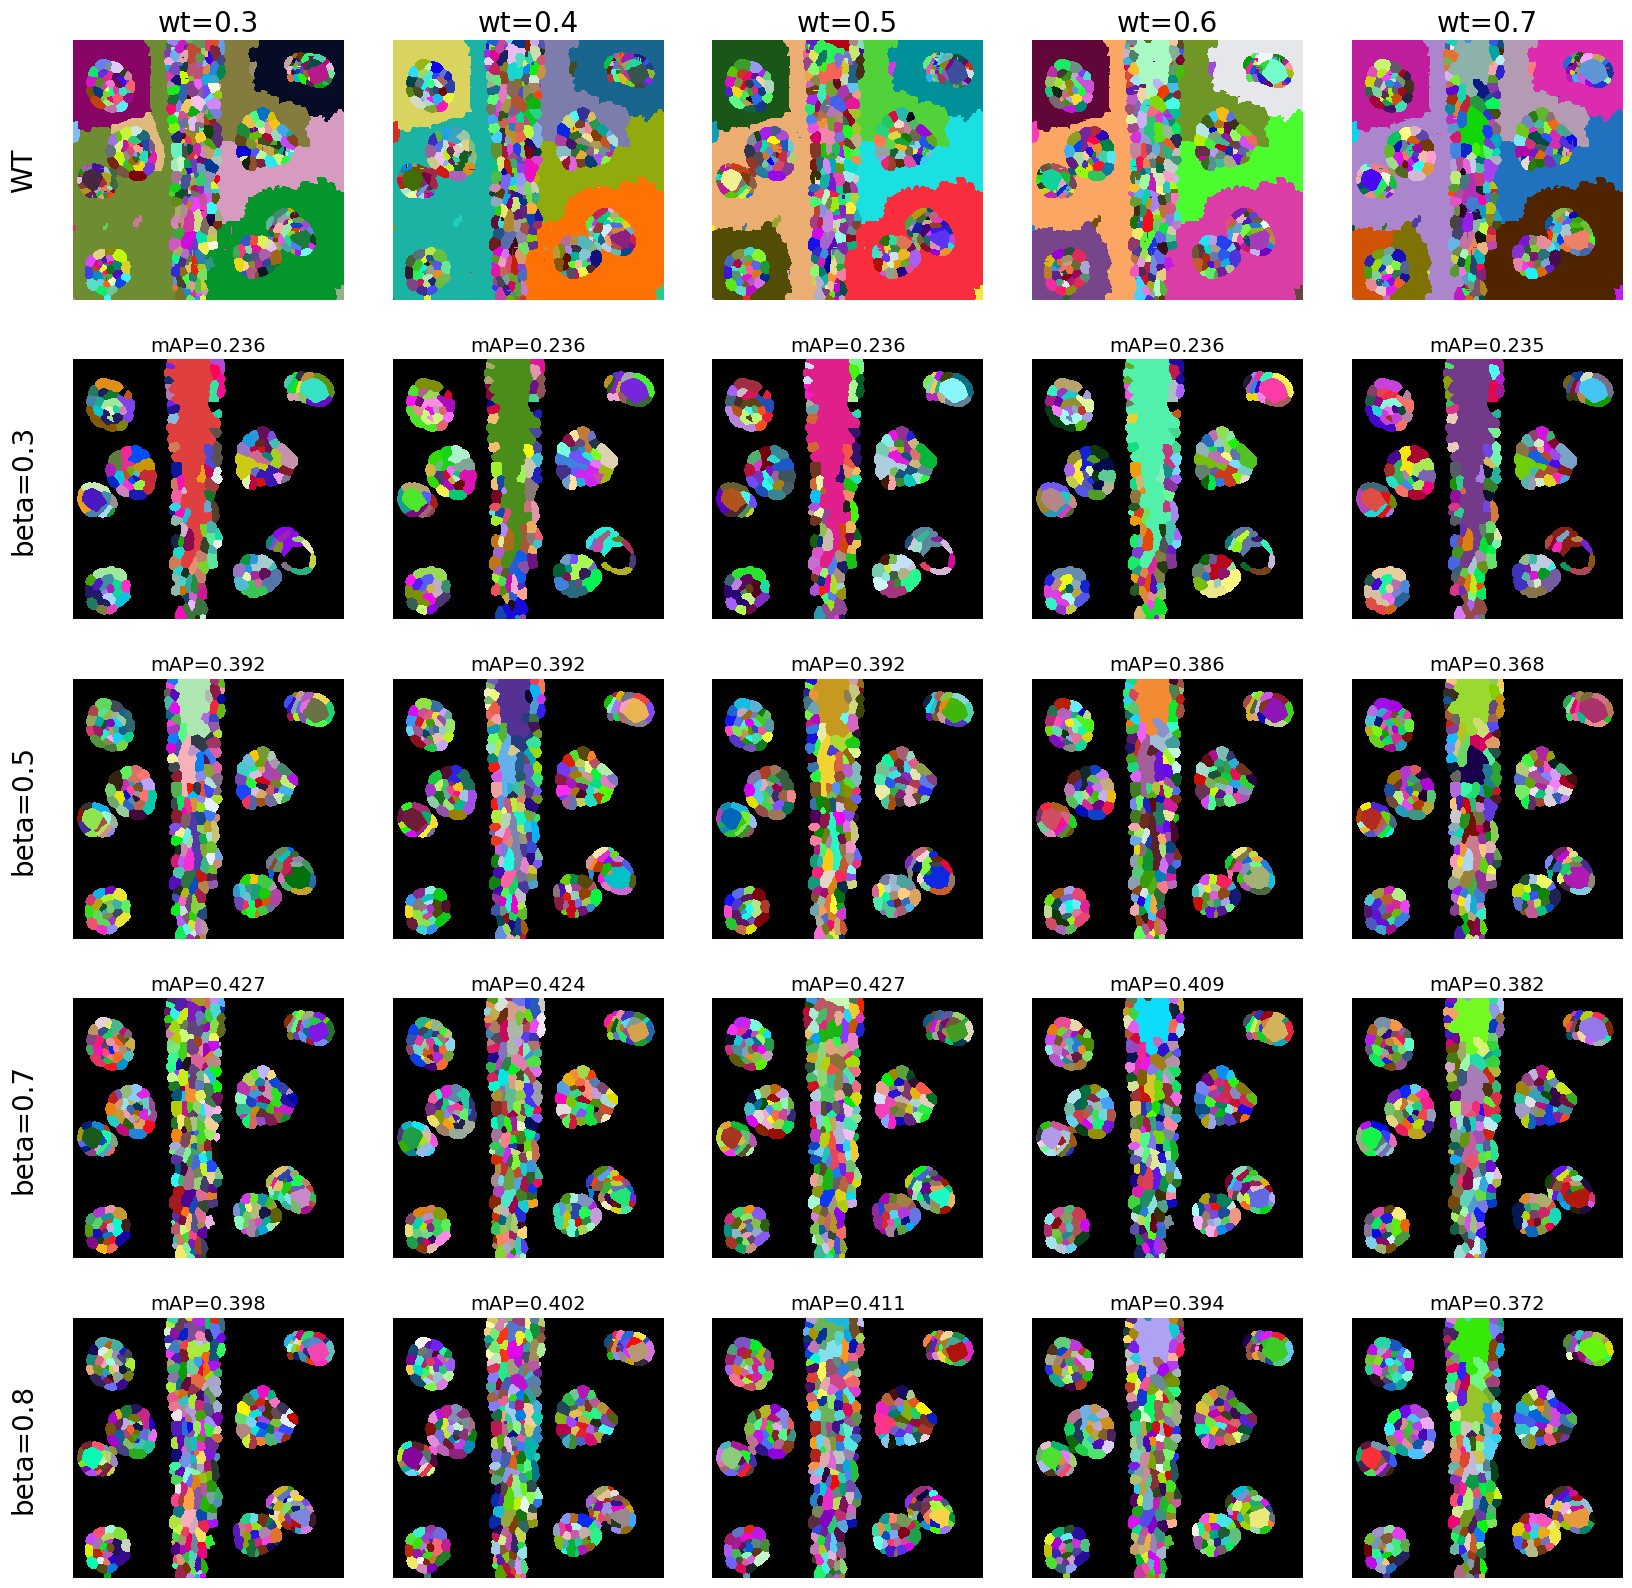

In [ ]:
# ...existing code...
i = 200
wt_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
gasp_betas = [0.3, 0.5, 0.7, 0.8]

pred = preds_NA[i].squeeze()
n_rows = 1 + len(gasp_betas)
n_cols = len(wt_thresholds)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(20, 20))

for col, th in enumerate(wt_thresholds):
    pred_wt = dt_watershed(pred, threshold=th, stacked=False, min_size=5)

    axs[0, col].imshow(
        pred_wt,
        cmap=get_random_colors(pred_wt),
        interpolation="nearest"
    )
    axs[0, col].axis("off")
    axs[0, col].set_title(f"wt={th}", fontsize=20)

    if col == 0:
        axs[0, col].text(
            -0.18, 0.5, "WT",
            transform=axs[0, col].transAxes,
            va="center", ha="center",
            rotation=90, fontsize=20,
            clip_on=False
        )

    for row, beta in enumerate(gasp_betas, start=1):
        gasp_pred = gasp(pred, pred_wt, post_minsize=50, beta=beta)
        gasp_pred = set_biggest_instance_to_zero(gasp_pred)
        gasp_pred = set_biggest_instance_to_zero(gasp_pred)

        map_score = MAP_metric(
            torch.from_numpy(gasp_pred).unsqueeze(0).unsqueeze(0).unsqueeze(0), 
            torch.from_numpy(OV_gt[i]).unsqueeze(0).unsqueeze(0).unsqueeze(0)
        )[0].item()

        axs[row, col].imshow(
            gasp_pred,
            cmap=get_random_colors(gasp_pred),
            interpolation="nearest"
        )
        axs[row, col].axis("off")
        axs[row, col].set_title(f"mAP={map_score:.3f}", fontsize=14, pad=6)

        if col == 0:
            axs[row, col].text(
                -0.18, 0.5, f"beta={beta}",
                transform=axs[row, col].transAxes,
                va="center", ha="center",
                rotation=90, fontsize=20,
                clip_on=False
            )

plt.subplots_adjust(wspace=0.18, hspace=0.22)
plt.savefig(
    "/g/kreshuk/talks/model_ranking/notebooks/thesis/cells/figures/Ovules_wt_gasp_grid.png",
    dpi=500, bbox_inches="tight", pad_inches=0
)
plt.savefig(
    "/g/kreshuk/talks/model_ranking/notebooks/thesis/cells/figures/Ovules_wt_gasp_grid.svg",
    bbox_inches="tight", pad_inches=0, format="svg"
)
plt.show()
# ...existing code...